# Approach 2: VAD-Only Speech Segmentation

This notebook implements the **VAD-only baseline** for the YOYO assignment using **Silero VAD**.

Goal:
- detect speech timestamps in each audio file
- merge nearby speech regions into larger candidate interaction windows
- split long recordings into conversation candidates using large silence gaps

Important limitation:
> This approach detects **all speech**, not specifically customer-facing speech. It is a strong candidate generator, but it can still include staff-only speech and unrelated shop-floor talk.


In [1]:
# Run this once in a fresh environment if needed.
# %pip install -q "numpy<2" silero-vad torch torchaudio librosa soundfile matplotlib pandas ipython


In [2]:
from __future__ import annotations

import json
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".mpl_cache").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchaudio
from silero_vad import get_speech_timestamps, load_silero_vad

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

torch.set_num_threads(1)


In [3]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        has_audio = (candidate / "audio").exists()
        has_repo_marker = (candidate / "ground_truth.json").exists() or (candidate / "approaches").exists() or (candidate / "context.md").exists()
        if has_audio and has_repo_marker:
            return candidate
        # If the notebook is launched from inside approaches/, the parent is the project root.
        if candidate.name == "approaches" and (candidate.parent / "audio").exists():
            return candidate.parent
    raise FileNotFoundError(
        "Could not find project root. Expected a folder containing audio/ and ground_truth.json or approaches/. "
        f"Current working directory was: {start}"
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUTPUT_DIR = PROJECT_ROOT / "approaches" / "approach_2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "audio_dir": PROJECT_ROOT / "audio",
    "output_dir": OUTPUT_DIR,
    "target_sr": 16000,
    "threshold": 0.5,
    "min_speech_duration_ms": 250,
    "max_speech_duration_s": float("inf"),
    "min_silence_duration_ms": 400,
    "speech_pad_ms": 200,
    "merge_gap_s": 1.0,
    "min_region_s": 1.5,
    "conversation_gap_s": 5.0,
    "plot_width": 18,
    "plot_height": 4,
}

audio_files = sorted(CONFIG["audio_dir"].glob("*.mp3"))
print("Project root:", PROJECT_ROOT)
print("Audio dir:", CONFIG["audio_dir"])
print("Audio files:", [path.name for path in audio_files])
print("Outputs:", CONFIG["output_dir"])

import sys
sys.path.append(str(PROJECT_ROOT / "approaches"))
from output_utils import load_ground_truth, export_uniform_outputs, export_combined_outputs

GROUND_TRUTH = load_ground_truth(PROJECT_ROOT)


Project root: /teamspace/studios/this_studio
Audio dir: /teamspace/studios/this_studio/audio
Audio files: ['Sample1KN.mp3', 'Sample2EN.mp3', 'sample3KN.mp3']
Outputs: /teamspace/studios/this_studio/approaches/approach_2_outputs


In [4]:
def format_time(seconds: float) -> str:
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:02d}:{secs:06.3f}"


def load_audio_mono_resampled(path: str | Path, target_sr: int = 16000):
    waveform, sr = torchaudio.load(str(path))

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
        sr = target_sr

    return waveform.squeeze(0).contiguous(), sr


VAD_MODEL = load_silero_vad()


def run_silero_vad_on_tensor(waveform: torch.Tensor, sr: int, cfg: dict):
    speech = get_speech_timestamps(
        waveform,
        VAD_MODEL,
        sampling_rate=sr,
        threshold=cfg["threshold"],
        min_speech_duration_ms=cfg["min_speech_duration_ms"],
        max_speech_duration_s=cfg["max_speech_duration_s"],
        min_silence_duration_ms=cfg["min_silence_duration_ms"],
        speech_pad_ms=cfg["speech_pad_ms"],
        return_seconds=False,
    )

    return [
        {
            "segment_id": idx + 1,
            "start": seg["start"] / sr,
            "end": seg["end"] / sr,
            "duration": (seg["end"] - seg["start"]) / sr,
        }
        for idx, seg in enumerate(speech)
    ]


def merge_close_segments(segments: list[dict], merge_gap_s: float, min_region_s: float):
    if not segments:
        return []

    merged = []
    current = segments[0].copy()

    for seg in segments[1:]:
        if seg["start"] - current["end"] <= merge_gap_s:
            current["end"] = max(current["end"], seg["end"])
        else:
            current["duration"] = current["end"] - current["start"]
            if current["duration"] >= min_region_s:
                merged.append(current)
            current = seg.copy()

    current["duration"] = current["end"] - current["start"]
    if current["duration"] >= min_region_s:
        merged.append(current)

    return [
        {
            "region_id": idx + 1,
            "start": seg["start"],
            "end": seg["end"],
            "duration": seg["duration"],
        }
        for idx, seg in enumerate(merged)
    ]


def assign_conversation_ids(regions: list[dict], conversation_gap_s: float):
    if not regions:
        return []

    rows = []
    conversation_id = 1
    previous_end = None

    for region in regions:
        if previous_end is not None and region["start"] - previous_end > conversation_gap_s:
            conversation_id += 1

        row = region.copy()
        row["conversation_id"] = conversation_id
        rows.append(row)
        previous_end = region["end"]

    return rows


def collapse_conversation_groups(region_rows: list[dict]):
    if not region_rows:
        return []

    grouped = []
    current_id = region_rows[0]["conversation_id"]
    current_start = region_rows[0]["start"]
    current_end = region_rows[0]["end"]
    region_count = 1

    for row in region_rows[1:]:
        if row["conversation_id"] == current_id:
            current_end = max(current_end, row["end"])
            region_count += 1
        else:
            grouped.append(
                {
                    "conversation_id": current_id,
                    "start": current_start,
                    "end": current_end,
                    "duration": current_end - current_start,
                    "num_regions": region_count,
                }
            )
            current_id = row["conversation_id"]
            current_start = row["start"]
            current_end = row["end"]
            region_count = 1

    grouped.append(
        {
            "conversation_id": current_id,
            "start": current_start,
            "end": current_end,
            "duration": current_end - current_start,
            "num_regions": region_count,
        }
    )

    return grouped


In [5]:
def add_readable_times(rows: list[dict]):
    for row in rows:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])
    return rows


def plot_waveform_with_segments(waveform, sr, segments, title="Waveform with VAD segments"):
    times = np.arange(len(waveform)) / sr

    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(times, waveform.numpy(), linewidth=0.6)

    for seg in segments:
        plt.axvspan(seg["start"], seg["end"], alpha=0.25)

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


def plot_waveform_with_conversations(waveform, sr, convs, title="Waveform with conversation candidates"):
    times = np.arange(len(waveform)) / sr
    peak = max(float(waveform.abs().max()), 1e-6)

    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(times, waveform.numpy(), linewidth=0.6)

    for conv in convs:
        plt.axvspan(conv["start"], conv["end"], alpha=0.2)
        plt.text(conv["start"], peak * 0.8, f"Conv {conv['conversation_id']}", fontsize=10)

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


def process_audio_file(audio_path: str | Path, cfg: dict):
    waveform, sr = load_audio_mono_resampled(audio_path, target_sr=cfg["target_sr"])

    speech_segments = add_readable_times(run_silero_vad_on_tensor(waveform, sr, cfg))
    merged_regions = add_readable_times(
        merge_close_segments(
            speech_segments,
            merge_gap_s=cfg["merge_gap_s"],
            min_region_s=cfg["min_region_s"],
        )
    )
    region_rows = add_readable_times(
        assign_conversation_ids(
            merged_regions,
            conversation_gap_s=cfg["conversation_gap_s"],
        )
    )
    conversation_rows = add_readable_times(collapse_conversation_groups(region_rows))

    return {
        "audio_path": str(audio_path),
        "audio_name": Path(audio_path).name,
        "sample_rate": sr,
        "duration_s": len(waveform) / sr,
        "waveform": waveform,
        "speech_segments": speech_segments,
        "merged_regions": merged_regions,
        "conversation_candidates": conversation_rows,
    }


def export_result_tables(result: dict, output_dir: Path):
    return export_uniform_outputs(
        output_dir=output_dir,
        audio_name=result["audio_name"],
        approach_name="approach_2_vad",
        conversation_candidates=pd.DataFrame(result["conversation_candidates"]),
        final_two=pd.DataFrame(result.get("final_two_conversations", [])),
        ground_truth=GROUND_TRUTH,
        final_selection_method="top_2_longest_vad_candidates",
    )


In [6]:
results = [process_audio_file(path, CONFIG) for path in audio_files]

summary_rows = []
exported_outputs = []
for result in results:
    exported_outputs.append(export_result_tables(result, CONFIG["output_dir"]))
    summary_rows.append(
        {
            "audio_name": result["audio_name"],
            "duration_s": round(result["duration_s"], 2),
            "speech_segments": len(result["speech_segments"]),
            "merged_regions": len(result["merged_regions"]),
            "conversation_candidates": len(result["conversation_candidates"]),
        }
    )

summary_df = pd.DataFrame(summary_rows)
combined_outputs = export_combined_outputs(CONFIG["output_dir"] if "CONFIG" in globals() else OUTPUT_DIR, exported_outputs)

display(summary_df)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


,audio_name,duration_s,speech_segments,merged_regions,conversation_candidates
0,Sample1KN.mp3,661.8,65,29,13
1,Sample2EN.mp3,921.7,147,48,17
2,sample3KN.mp3,362.5,74,27,7


In [7]:
example_result = results[0]

print("Audio:", example_result["audio_name"])
print("Duration:", round(example_result["duration_s"], 2), "seconds")
print("Detected speech segments:", len(example_result["speech_segments"]))
print("Detected merged regions:", len(example_result["merged_regions"]))
print("Conversation candidates:", len(example_result["conversation_candidates"]))

display(pd.DataFrame(example_result["speech_segments"]).head(20))
display(pd.DataFrame(example_result["merged_regions"]))
display(pd.DataFrame(example_result["conversation_candidates"]))


Audio: Sample1KN.mp3
Duration: 661.8 seconds
Detected speech segments: 65
Detected merged regions: 29
Conversation candidates: 13


,segment_id,start,end,duration,start_hms,end_hms
0,1,4.120,6.408,2.288,00:04.120,00:06.408
1,2,7.640,9.000,1.360,00:07.640,00:09.000
2,3,9.176,17.928,8.752,00:09.176,00:17.928
3,4,18.360,19.272,0.912,00:18.360,00:19.272
4,5,19.736,20.648,0.912,00:19.736,00:20.648
5,6,21.720,26.280,4.560,00:21.720,00:26.280
6,7,28.728,30.344,1.616,00:28.728,00:30.344
7,8,31.448,32.424,0.976,00:31.448,00:32.424
8,9,32.856,33.704,0.848,00:32.856,00:33.704
9,10,34.104,38.504,4.400,00:34.104,00:38.504


,region_id,start,end,duration,start_hms,end_hms
0,1,4.120,6.408,2.288,00:04.120,00:06.408
1,2,7.640,20.648,13.008,00:07.640,00:20.648
2,3,21.720,26.280,4.560,00:21.720,00:26.280
3,4,28.728,30.344,1.616,00:28.728,00:30.344
4,5,31.448,38.504,7.056,00:31.448,00:38.504
5,6,56.952,59.080,2.128,00:56.952,00:59.080
6,7,60.568,65.960,5.392,01:00.568,01:05.960
7,8,105.848,108.936,3.088,01:45.848,01:48.936
8,9,112.536,120.584,8.048,01:52.536,02:00.584
9,10,122.360,127.240,4.880,02:02.360,02:07.240


,conversation_id,start,end,duration,num_regions,start_hms,end_hms
0,1,4.120,38.504,34.384,5,00:04.120,00:38.504
1,2,56.952,65.960,9.008,2,00:56.952,01:05.960
2,3,105.848,138.312,32.464,5,01:45.848,02:18.312
3,4,172.600,175.336,2.736,1,02:52.600,02:55.336
4,5,267.960,308.392,40.432,2,04:27.960,05:08.392
5,6,322.616,334.728,12.112,2,05:22.616,05:34.728
6,7,340.152,370.728,30.576,2,05:40.152,06:10.728
7,8,376.376,383.048,6.672,1,06:16.376,06:23.048
8,9,417.688,428.808,11.120,2,06:57.688,07:08.808
9,10,449.048,452.200,3.152,1,07:29.048,07:32.200


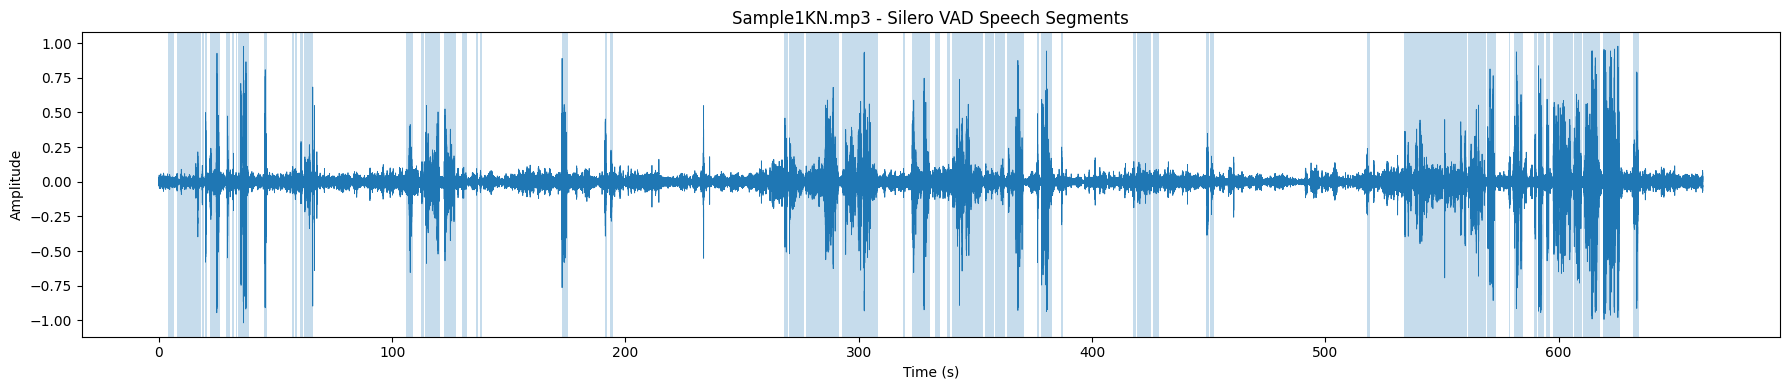

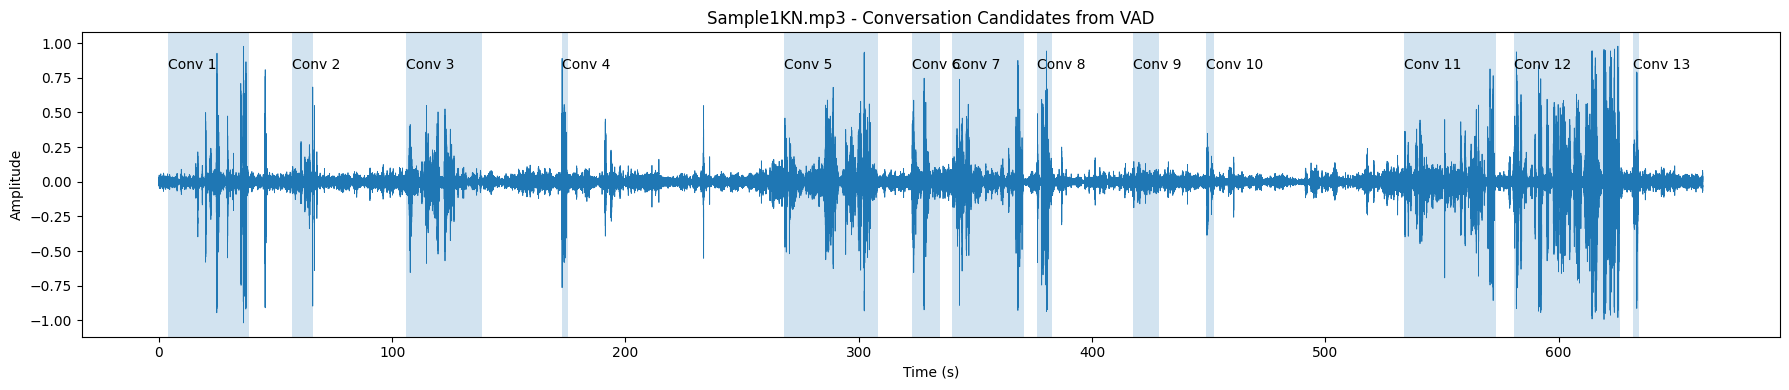

In [8]:
plot_waveform_with_segments(
    example_result["waveform"],
    example_result["sample_rate"],
    example_result["speech_segments"],
    title=f"{example_result['audio_name']} - Silero VAD Speech Segments",
)

plot_waveform_with_conversations(
    example_result["waveform"],
    example_result["sample_rate"],
    example_result["conversation_candidates"],
    title=f"{example_result['audio_name']} - Conversation Candidates from VAD",
)


## Standard Outputs

Each approach now writes the same comparable output structure. For each audio file:

- `*_conversation_candidates.csv`: candidate conversation blocks generated by this approach.
- `*_final_two_conversations.csv`: the final predicted two customer conversation windows.
- `*_tagged_conversation_candidates.csv`: the candidate blocks annotated with whether they contributed to customer 1, customer 2, or were not selected.

At the approach folder level:

- `all_files_final_two_conversations.csv`: final predictions across all audio files.
- `evaluation_against_ground_truth.csv`: per-conversation boundary errors and IoU when `ground_truth.json` is available.
- `evaluation_summary.csv`: per-file mean absolute start error, mean absolute end error, and mean IoU.
